# Terna mix elettrico 2023-2024 — validazione dati

Notebook tecnico. Genera le figure per il README.

**Dataset**: `terna_electricity_by_source` (Terna) via GCS clean parquet.
**Serie**: 2023-2024.

Per la narrativa completa vedi il [README](../README.md).


In [1]:
import duckdb, json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from IPython.display import display
pd.options.display.float_format = '{:,.0f}'.format
plt.rcParams['figure.dpi'] = 150

con = duckdb.connect()
con.execute("INSTALL httpfs; LOAD httpfs;")
GCS = 'gs://dataciviclab-clean/terna_electricity_by_source/*/terna_electricity_by_source_*_clean.parquet'

# Verifica
anni = con.execute(f"SELECT DISTINCT anno FROM read_parquet('{GCS}') ORDER BY anno").fetchdf()
print(f"Anni: {list(anni['anno'])}")


Anni: [2023, 2024]


In [2]:
# 1. Mix nazionale per fonte (produzione netta)
trend = con.execute(f"""
    SELECT anno, fonte,
           CAST(SUM(produzione_gwh) AS BIGINT) AS gwh
    FROM read_parquet('{GCS}')
    WHERE tipo_produzione = 'Netta'
    GROUP BY anno, fonte
    ORDER BY anno, gwh DESC
""").fetchdf()

display(trend)

print(f"\nTermoelettrico: {int(trend[(trend['anno']==2023)&(trend['fonte']=='Termoelettrico')]['gwh'].values[0]):,} -> {int(trend[(trend['anno']==2024)&(trend['fonte']=='Termoelettrico')]['gwh'].values[0]):,} GWh")
print(f"Rinnovabili: {int(trend[(trend['anno']==2023)&(trend['fonte']!='Termoelettrico')]['gwh'].sum()):,} -> {int(trend[(trend['anno']==2024)&(trend['fonte']!='Termoelettrico')]['gwh'].sum()):,} GWh")


,anno,fonte,gwh
0,2023,Termoelettrico,162588
1,2023,Idrico,42068
2,2023,Fotovoltaico,30711
3,2023,Eolico,23640
4,2023,Geotermoelettrico,5692
5,2023,Accumulo Stand Alone,8
6,2024,Termoelettrico,152080
7,2024,Idrico,54757
8,2024,Fotovoltaico,35993
9,2024,Eolico,22322



Termoelettrico: 162,588 -> 152,080 GWh
Rinnovabili: 102,119 -> 118,883 GWh


In [3]:
# 2. Quote fossili vs rinnovabili
quote = con.execute(f"""
    SELECT anno,
           CAST(SUM(CASE WHEN fonte = 'Termoelettrico' THEN produzione_gwh ELSE 0 END) AS BIGINT) AS termoelettrico,
           CAST(SUM(CASE WHEN fonte != 'Termoelettrico' THEN produzione_gwh ELSE 0 END) AS BIGINT) AS rinnovabile,
           ROUND(CAST(SUM(CASE WHEN fonte != 'Termoelettrico' THEN produzione_gwh ELSE 0 END) AS DOUBLE) * 100.0
                 / NULLIF(CAST(SUM(produzione_gwh) AS DOUBLE), 0), 1) AS pct_rinnovabile
    FROM read_parquet('{GCS}')
    WHERE tipo_produzione = 'Netta'
    GROUP BY anno
    ORDER BY anno
""").fetchdf()

display(quote)

print(f"Quota rinnovabili: {quote[quote['anno']==2023]['pct_rinnovabile'].values[0]}% -> {quote[quote['anno']==2024]['pct_rinnovabile'].values[0]}%")


,anno,termoelettrico,rinnovabile,pct_rinnovabile
0,2023,162588,102120,39
1,2024,152080,118883,44


Quota rinnovabili: 38.6% -> 43.9%


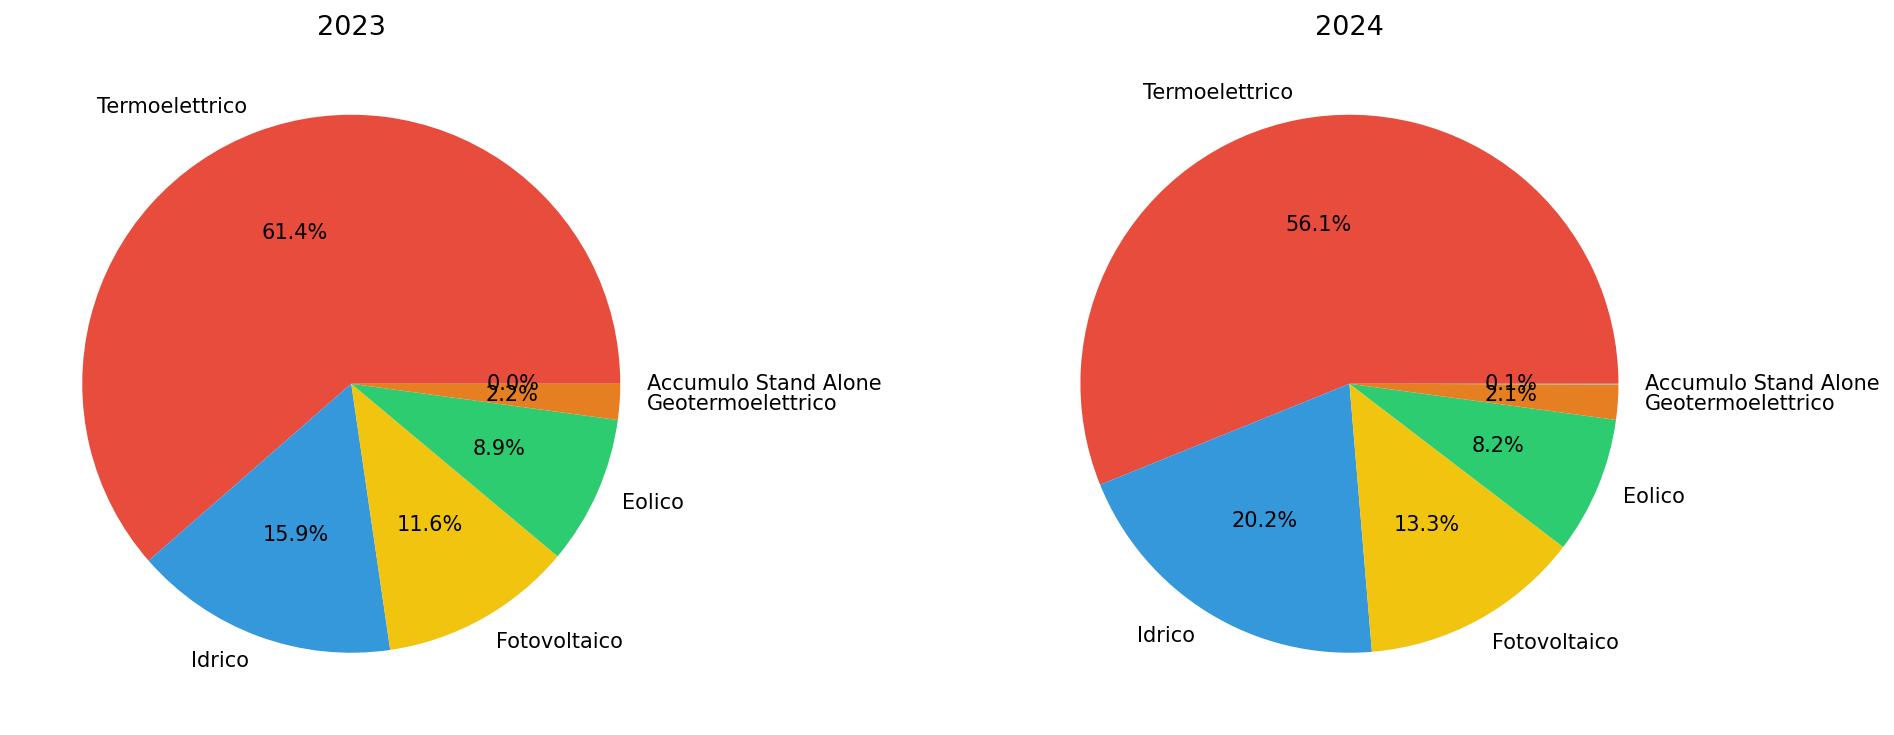

Salvato: figures/terna_mix_2023_2024.png


In [4]:
# Grafico: mix elettrico 2023 vs 2024
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
colors = {'Termoelettrico': '#e74c3c', 'Idrico': '#3498db', 'Fotovoltaico': '#f1c40f',
          'Eolico': '#2ecc71', 'Geotermoelettrico': '#e67e22', 'Accumulo Stand Alone': '#95a5a6'}

for idx, anno in enumerate([2023, 2024]):
    ax = [ax1, ax2][idx]
    data = trend[trend['anno'] == anno].set_index('fonte')['gwh']
    wedges, texts, autotexts = ax.pie(data, labels=data.index, autopct='%1.1f%%',
                                     colors=[colors.get(f, '#bdc3c7') for f in data.index])
    ax.set_title(f'{anno}', fontsize=13)

plt.tight_layout()
plt.savefig('../figures/terna_mix_2023_2024.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvato: figures/terna_mix_2023_2024.png')


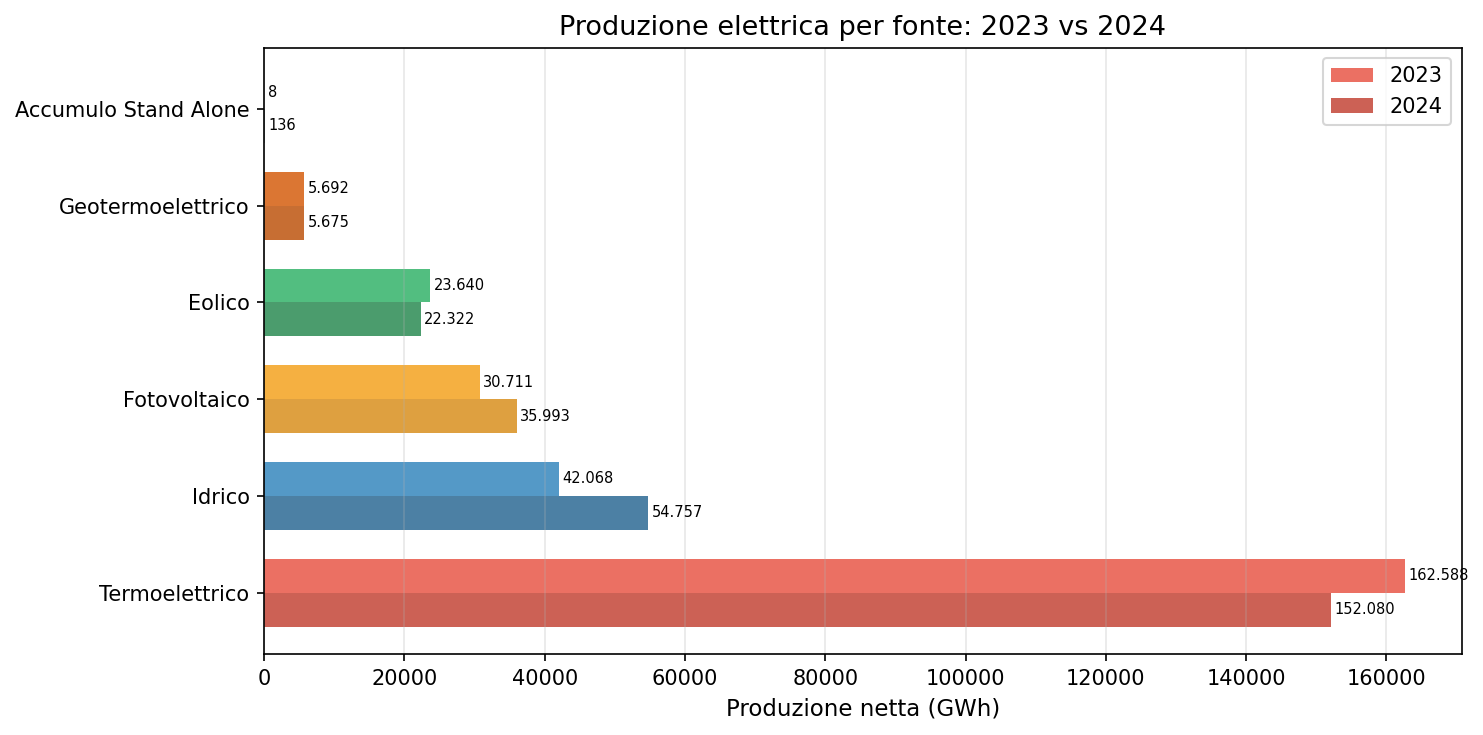

Salvato: figures/terna_barre_2023_2024.png


In [5]:
# Grafico: produzione per fonte 2023 vs 2024
fig, ax = plt.subplots(figsize=(10, 5))

plot_data = trend.pivot(index='fonte', columns='anno', values='gwh').fillna(0)
plot_data = plot_data.reindex(['Termoelettrico','Idrico','Fotovoltaico','Eolico','Geotermoelettrico','Accumulo Stand Alone'])

x = range(len(plot_data))
w = 0.35
colors_2023 = ['#e74c3c','#2980b9','#f39c12','#27ae60','#d35400','#bdc3c7']
colors_2024 = ['#c0392b','#1f618d','#d68910','#1e8449','#ba4a00','#95a5a6']

bars1 = ax.barh([i + w/2 for i in x], plot_data[2023], w, label='2023', color=colors_2023, alpha=0.8)
bars2 = ax.barh([i - w/2 for i in x], plot_data[2024], w, label='2024', color=colors_2024, alpha=0.8)

ax.set_yticks(x)
ax.set_yticklabels(plot_data.index)
ax.set_xlabel('Produzione netta (GWh)', fontsize=11)
ax.set_title('Produzione elettrica per fonte: 2023 vs 2024', fontsize=13)
ax.legend()
ax.grid(alpha=0.3, axis='x')

for bars in [bars1, bars2]:
    for bar in bars:
        w = bar.get_width()
        ax.text(w + 500, bar.get_y() + bar.get_height()/2, f'{int(w):,}'.replace(',','.'), va='center', fontsize=7)

plt.tight_layout()
plt.savefig('../figures/terna_barre_2023_2024.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvato: figures/terna_barre_2023_2024.png')


In [6]:
# 3. Top regioni per rinnovabili (2024, netta)
regioni = con.execute(f"""
    SELECT regione,
           CAST(SUM(CASE WHEN fonte IN ('Fotovoltaico','Eolico','Idrico') THEN produzione_gwh ELSE 0 END) AS BIGINT) AS rinnovabile,
           CAST(SUM(produzione_gwh) AS BIGINT) AS totale,
           ROUND(CAST(SUM(CASE WHEN fonte IN ('Fotovoltaico','Eolico','Idrico') THEN produzione_gwh ELSE 0 END) AS DOUBLE) * 100.0
                 / NULLIF(CAST(SUM(produzione_gwh) AS DOUBLE), 0), 1) AS pct_rin
    FROM read_parquet('{GCS}')
    WHERE tipo_produzione = 'Netta' AND anno = 2024
    GROUP BY regione
    ORDER BY pct_rin DESC
""").fetchdf()

display(regioni)



,regione,rinnovabile,totale,pct_rin
0,Valle d'Aosta,3941,4002,98
1,Trentino-Alto Adige,13882,15365,90
2,Basilicata,3803,4321,88
3,Marche,1886,2381,79
4,Umbria,2005,3167,63
5,Veneto,8088,16133,50
6,Abruzzo,2735,5457,50
7,Friuli-Venezia Giulia,3139,6735,47
8,Sicilia,7163,16150,44
9,Lazio,4089,9341,44


In [7]:
con.close()
print("Completato.")


Completato.
